Student name: Basil AlMukhtar \
Student Number: 23315687

Task1: Example 6.6 (Cliff Walking Grid World) in the Reinforcement Learning Sutton and Barto’s text on Reinforcement Learning, 2nd Edition (2018)

* 2D grid cliff world is the environment.
* Agent can move up, down, left and right to reach the goal around obstacles and avoid falling off the cliff.
* Reward:
    * Reaching the goal: +10
    * Hitting the obstacle: -10
    * Avoiding cliff edge: -100
    * Moving to a free space: -1 (encourages the agent to find the shortest path) 

Q-Learning Formula:
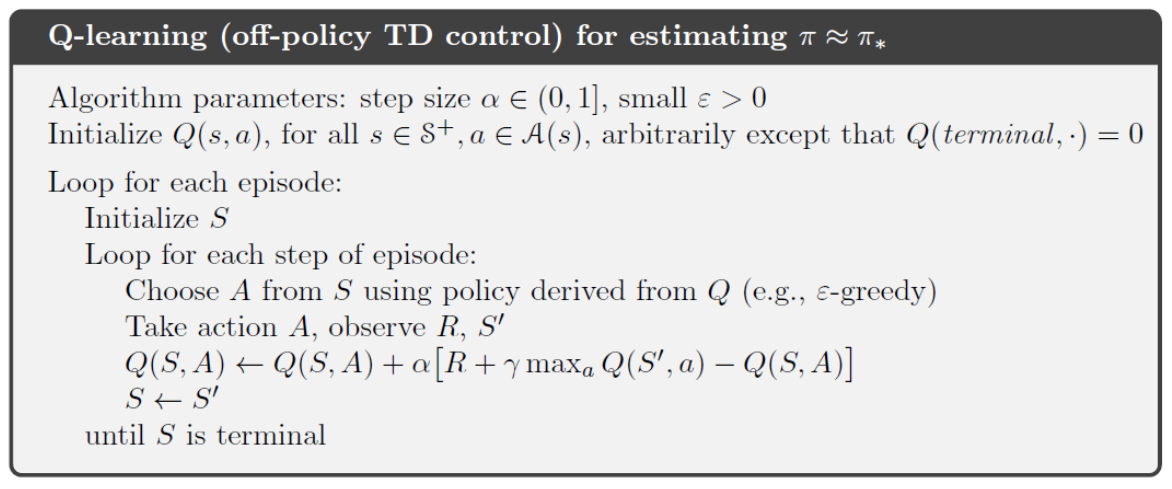 

SARSA Formula:
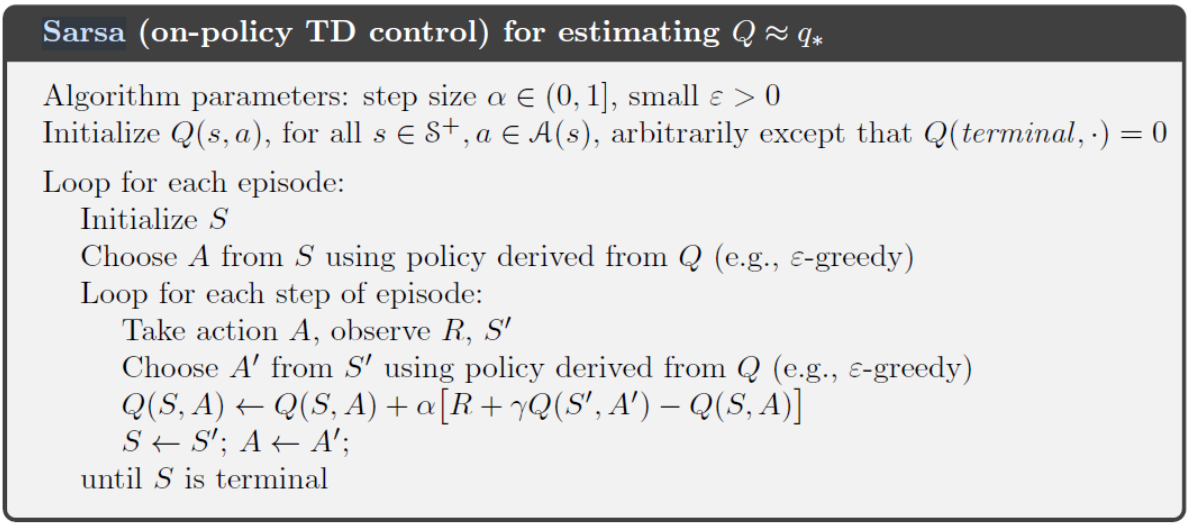

Where:
* Q(s,a): The Q-value for state s and action a
* Learning Rate (α): Controls how quickly the algorithm updates Q-values
* Exploration Rate (ϵ): Determines how often the agent tries new actions (explores) instead of using known best actions (exploits)
* Discount Factor (γ): Balances immediate and future reward 

Implementation:

A function to compare Q-learning and SARSA in terms of cumulative rewards and visualize their best policy paths, we both algorithms are implemented, their cumulative rewards over episodes is tracked, and plot the results. Finaly, we visualize the best policy paths for both algorithms on the grid.

In [110]:
def CliffWalk(grid, alpha = 0.1, gamma = 0.9, epsilon = 0.1):

    # Parameters
    alpha = alpha  # Learning rate
    gamma = gamma  # Discount factor
    epsilon = epsilon  # Exploration rate
    num_episodes = 500

    # Actions: up, down, left, right
    actions = ['up', 'down', 'left', 'right']

    # Helper function to get the next state given an action
    def get_next_state(state, action):
        i, j = state
        if action == 'up':
            i = max(i - 1, 0)
        elif action == 'down':
            i = min(i + 1, len(grid) - 1)
        elif action == 'left':
            j = max(j - 1, 0)
        elif action == 'right':
            j = min(j + 1, len(grid[0]) - 1)
        return (i, j)

    # Helper function to get the reward for a state
    def get_reward(state):
        i, j = state
        if grid[i][j] == 'G':
            return -1
        elif grid[i][j] == 'C':
            return -100
        elif grid[i][j] == '#':
            return -10
        else:
            return -1

    # Initialize Q-tables for Q-learning and SARSA
    Q_qlearning = {}
    Q_sarsa = {}
    for i in range(len(grid)):
        for j in range(len(grid[0])):
            Q_qlearning[(i, j)] = {a: 0 for a in actions}
            Q_sarsa[(i, j)] = {a: 0 for a in actions}

    # Track cumulative rewards for Q-learning and SARSA
    cumulative_rewards_qlearning = []
    cumulative_rewards_sarsa = []

    # Q-learning algorithm
    for episode in range(num_episodes):
        state = (3, 0)  # New start point at (3, 0)
        cumulative_reward = 0
    
        while grid[state[0]][state[1]] != 'G': # Run ploicy if an episode is not done
            # Choose action using epsilon-greedy policy
            if np.random.binomial(1, epsilon) == 1: #Normal distribution
                action = np.random.choice(actions)
            else:
                action = max(Q_qlearning[state], key=Q_qlearning[state].get)
   
            # Take action and observe next state and reward
            next_state = get_next_state(state, action)
            reward = get_reward(next_state)
            cumulative_reward += reward
        
            # Update Q-value using Q-learning
            # Q-learning updates the Q-value using the maximum Q-value of the next state.
            Q_qlearning[state][action] += alpha * (reward + gamma * max(Q_qlearning[next_state].values()) 
                                               - Q_qlearning[state][action])
        
            # Move to the next state
            state = next_state
            
       #The cumulative reward for each episode is tracked Q-Learning algorithms.
        cumulative_rewards_qlearning.append(cumulative_reward)

    # SARSA algorithm
    for episode in range(num_episodes):
        state = (3, 0)  # New start point at (3, 0)
        cumulative_reward = 0
    
        # Choose initial action using epsilon-greedy policy
        if np.random.binomial(1, epsilon) == 1: #Normal distribution
            action = np.random.choice(actions)
        else:
            action = max(Q_sarsa[state], key=Q_sarsa[state].get)
    
        while grid[state[0]][state[1]] != 'G': # Run ploicy if an episode is not done
            # Take action and observe next state and reward
            next_state = get_next_state(state, action)
            reward = get_reward(next_state)
            cumulative_reward += reward
        
            # Choose next action using epsilon-greedy policy
            if np.random.rand() < epsilon:
                next_action = np.random.choice(actions)
            else:
                next_action = max(Q_sarsa[next_state], key=Q_sarsa[next_state].get)
        
            # Update Q-value using SARSA
            # SARSA updates the Q-value using the action actually taken in the next state.
            Q_sarsa[state][action] += alpha * (reward + gamma * Q_sarsa[next_state][next_action] - Q_sarsa[state][action])
        
            # Move to the next state and action
            state, action = next_state, next_action
            
        #The acumulative reward for each episode is tracked SARSA algorithms.
        cumulative_rewards_sarsa.append(cumulative_reward)

    # A plot is generated to compare the cumulative rewards of Q-learning and SARSA over episodes.
    # The best policy path is extracted by following the greedy policy 
    #(i.e., choosing the action with the highest Q-value at each state).
    #The grid is visualized with the best policy path for both Q-learning and SARSA.
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_rewards_qlearning, label="Q-learning")
    plt.plot(cumulative_rewards_sarsa, label="SARSA")
    plt.xlabel("Episode")
    plt.ylabel("Cumulative Reward")
    plt.title("Q-learning vs SARSA: Cumulative Reward Comparison (Start at (3, 0))")
    plt.legend()
    plt.grid()
    plt.show()

    # Function to extract the best policy path
    def get_best_policy_path(Q, start_state):
        state = start_state
        path = [state]
        while grid[state[0]][state[1]] != 'G':
            action = max(Q[state], key=Q[state].get)
            state = get_next_state(state, action)
            path.append(state)
        return path

    # Get best policy paths for Q-learning and SARSA
    best_path_qlearning = get_best_policy_path(Q_qlearning, (3, 0))
    best_path_sarsa = get_best_policy_path(Q_sarsa, (3, 0))

    # Plot the grid with best policy paths
    def plot_grid_with_path(grid, path, title):
        grid_copy = [row.copy() for row in grid]
        for (i, j) in path:
            if grid_copy[i][j] not in ['S', 'G']:
                grid_copy[i][j] = '*'
    
        plt.figure(figsize=(12, 4))
        plt.imshow([[0 if cell == ' ' else 1 if cell == 'C' else 2 if cell == 'S' else 3 if cell == 'G' else 4 if cell == '#' 
                 else 5 for cell in row] for row in grid_copy], cmap='viridis')
        plt.title(title)
        plt.xticks([])
        plt.yticks([])
        for i in range(len(grid)):
            for j in range(len(grid[0])):
                plt.text(j, i, grid_copy[i][j], ha='center', va='center', color='white' if grid_copy[i][j] in ['C', 'S', 'G', '#'] else 'black')
        plt.show()

    # Plot best policy paths
    plot_grid_with_path(grid, best_path_qlearning, "Best Policy Path: Q-learning (Start at (3, 0))")
    plot_grid_with_path(grid, best_path_sarsa, "Best Policy Path: SARSA (Start at (3, 0))")

In [92]:
# Define a 2D grid cliff world walking where each cell can be a free space ' ', an obstacle '#', the start 'S', 
# a cliff edge 'C' or the goal'G'.
# CliffWalk Grid options with 12 columns and 4 rows across RL in Q-learning and SARSA algorithms.

grid1 = [
    [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
    [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
    [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
    ['S', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'G']
]

grid2 = [
    [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
    [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '#', ' ', ' '],
    [' ', '#', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
    ['S', ' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' ', ' ', 'G']
]

grid3 = [
    [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
    [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
    [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
    ['S', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'G']
]

grid4 = [
    [' ', ' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' ', ' '],
    [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '#', ' ', ' '],
    [' ', ' ', ' ', ' ', '#', ' ', ' ', ' ', ' ', ' ', ' '],
    ['S', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'G']
]

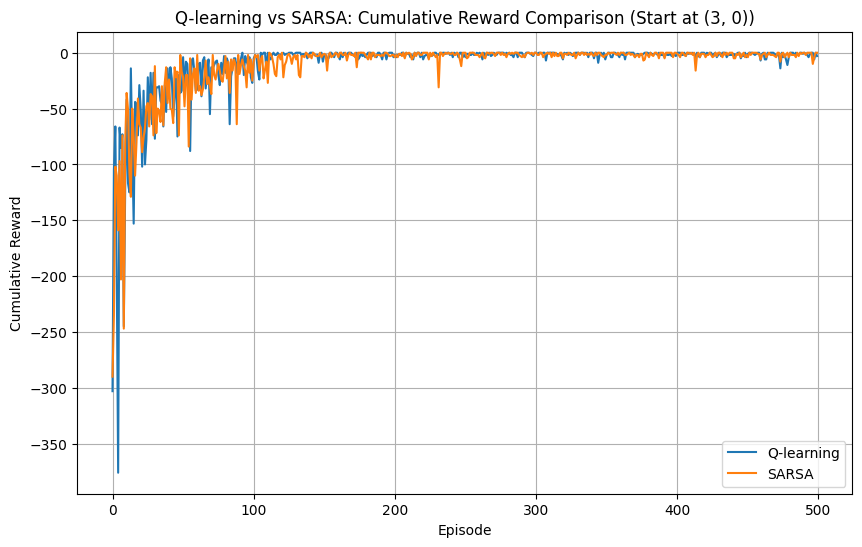

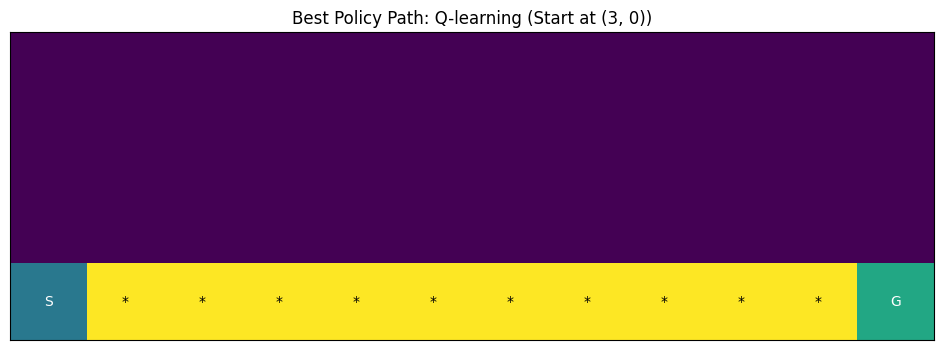

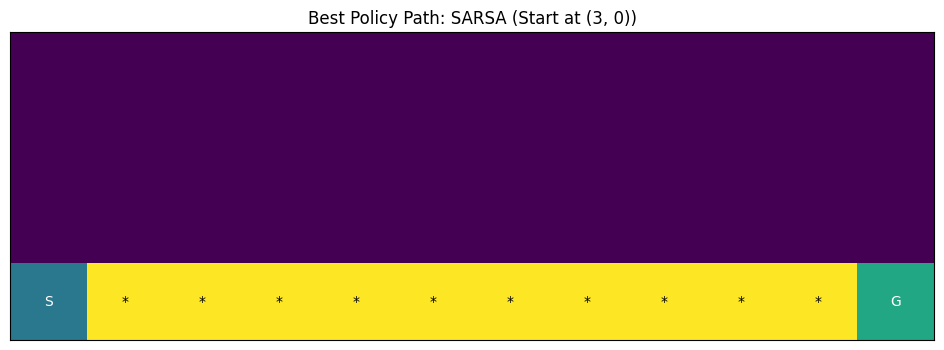

In [102]:
CliffWalk(grid1, alpha = 0.1, gamma = 0.9, epsilon = 0.1)

Both algorithms take shortest path to reach goal target

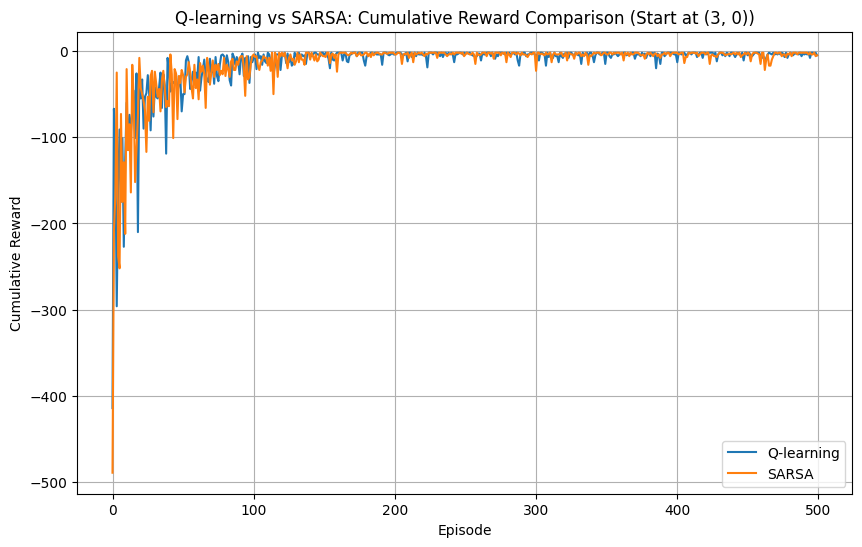

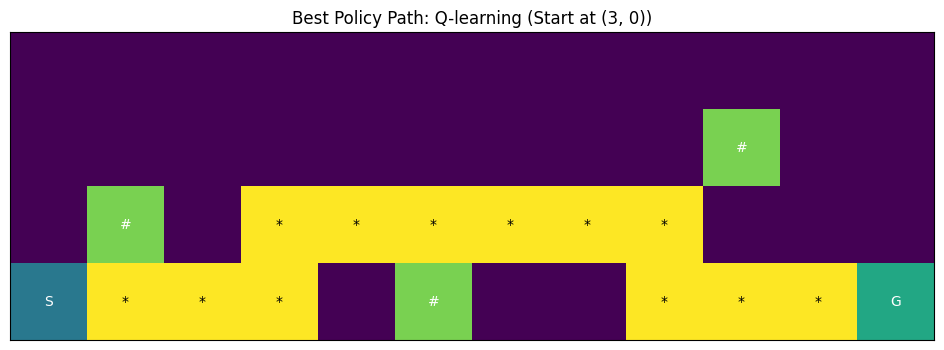

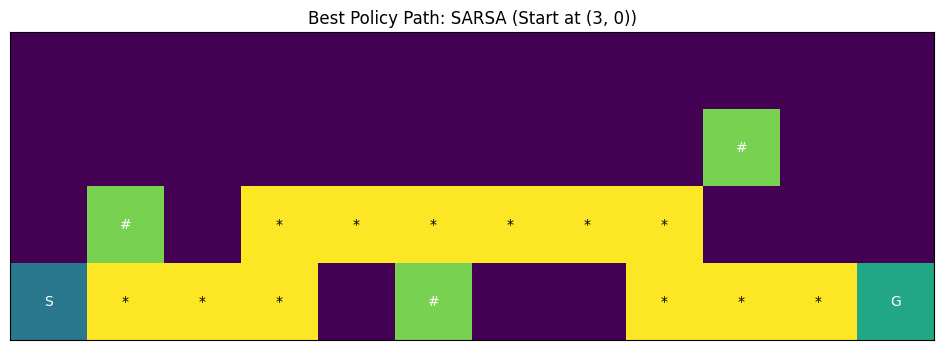

In [103]:
CliffWalk(grid2, alpha = 0.1, gamma = 0.9, epsilon = 0.1)

Both algorithms successfully avoiding the obstacles before reaching the goal target

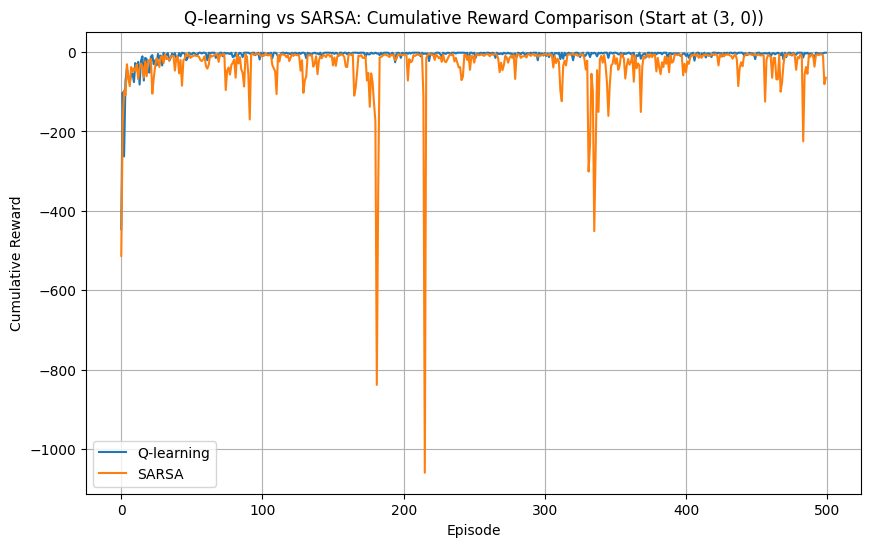

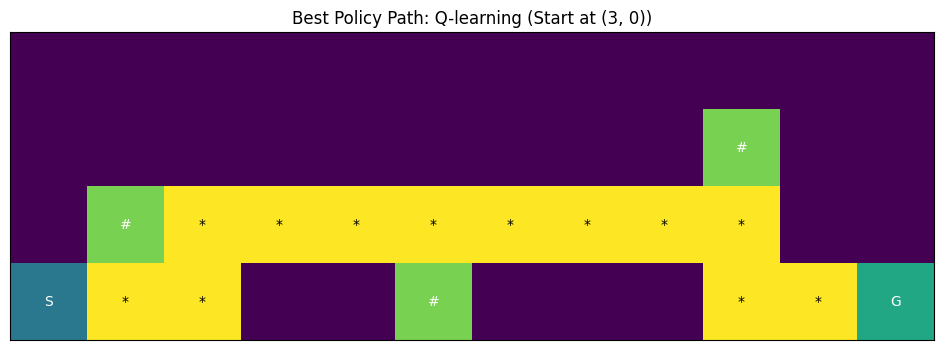

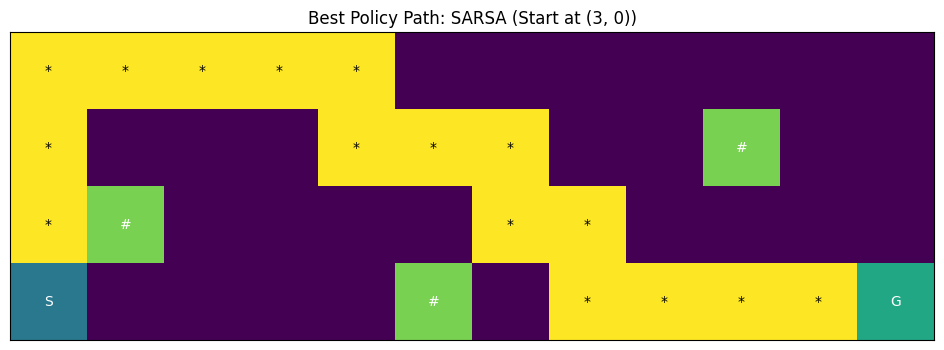

In [108]:
CliffWalk(grid2, alpha = 0.5, gamma = 0.5, epsilon = 0.1)

Increasing alpha and dropping Gamma (Discount factor). Learning rate is now faster. Sarsa takes the longer safer path to goal while Q-learning takes the shortest path.

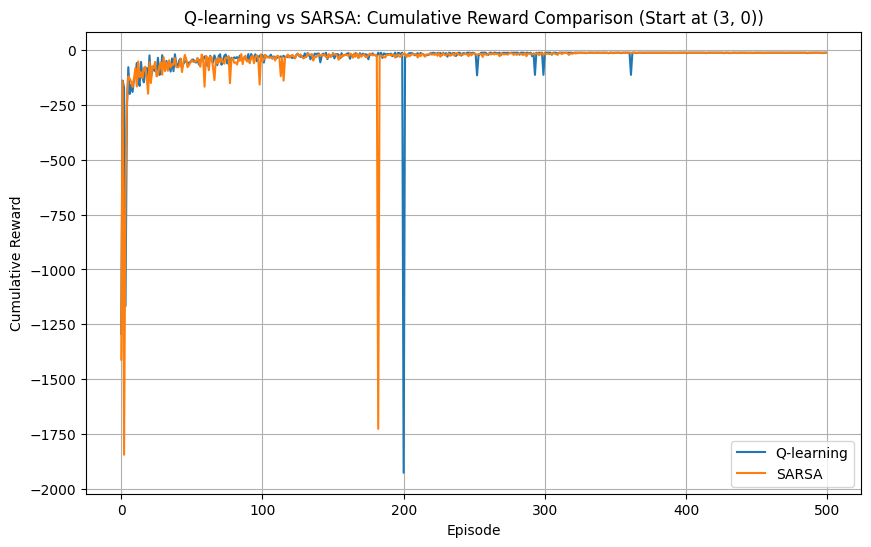

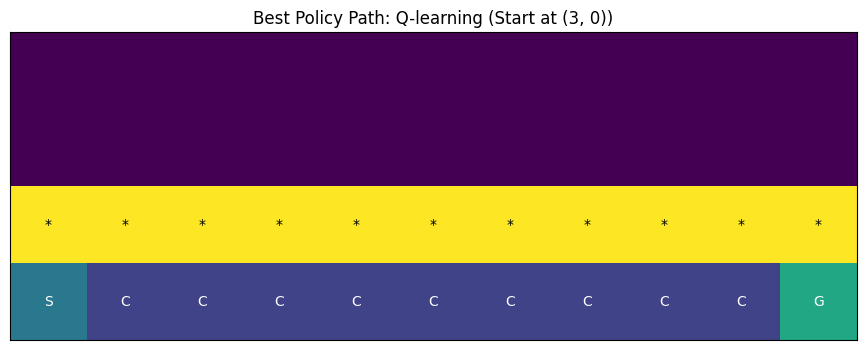

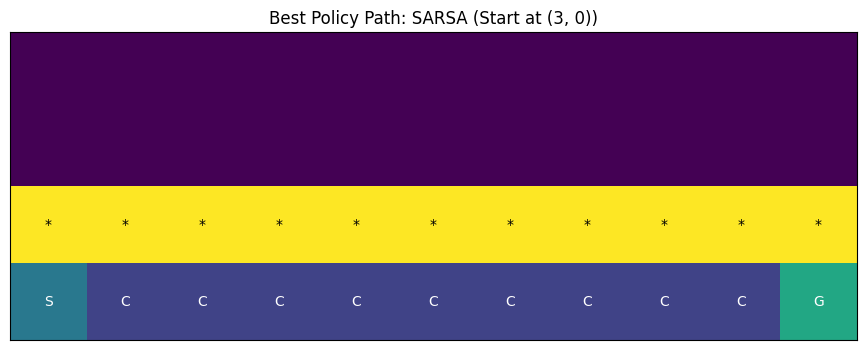

In [115]:
CliffWalk(grid3, alpha = 0.1, gamma = 0.9, epsilon = 0.01)

With small alpha both Q-learning ans sarsa have same optimal policy path. This is in line with text example ref.

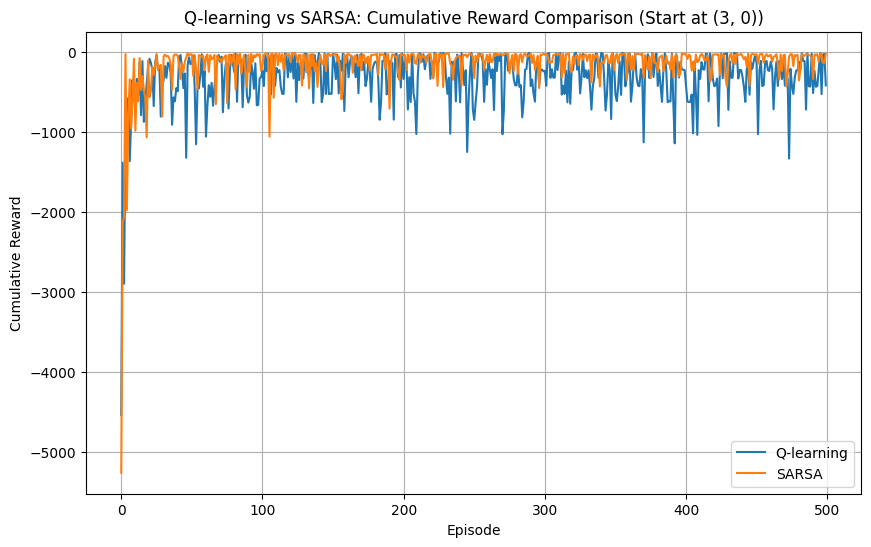

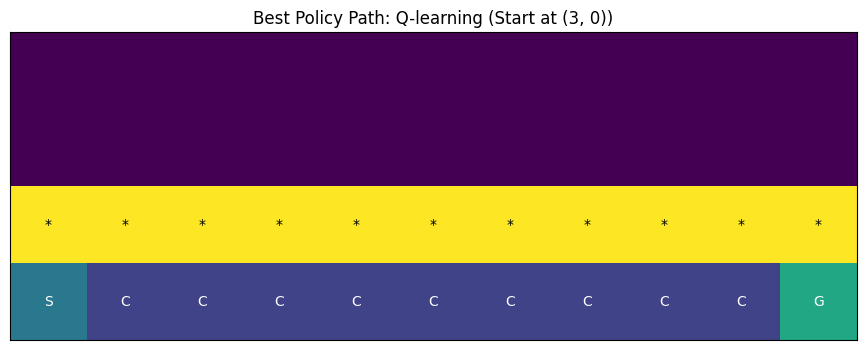

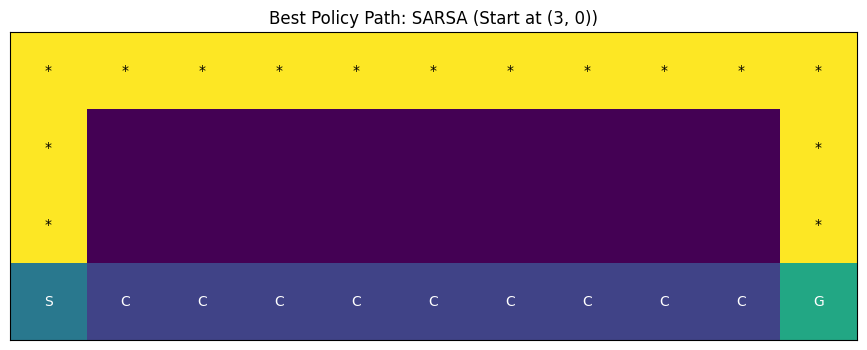

In [113]:
CliffWalk(grid3, alpha = 0.1, gamma = 0.9, epsilon = 0.5)

Increasing exploration rate, Sarsa now takes even longer safer path avoiding the cliff edge to goal while Q-learning takes the shortest path with cliff edge risk. This is in line with text example ref.

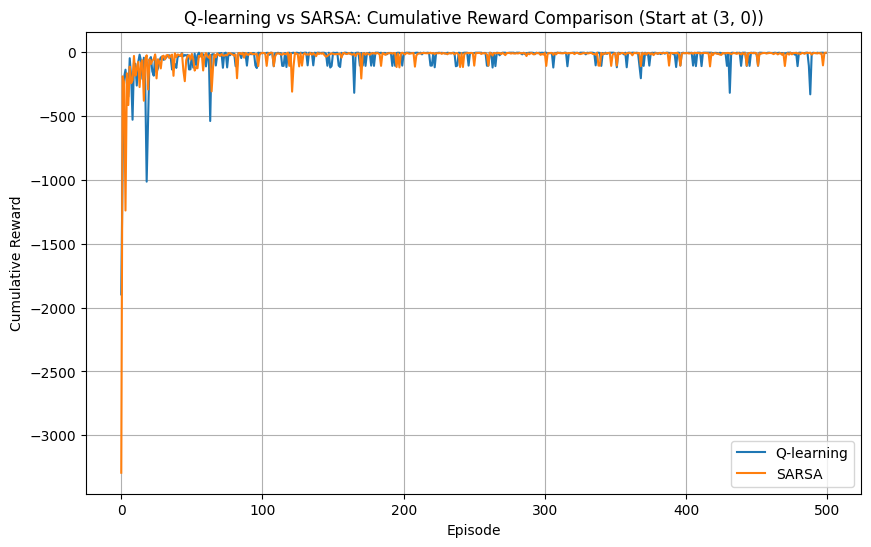

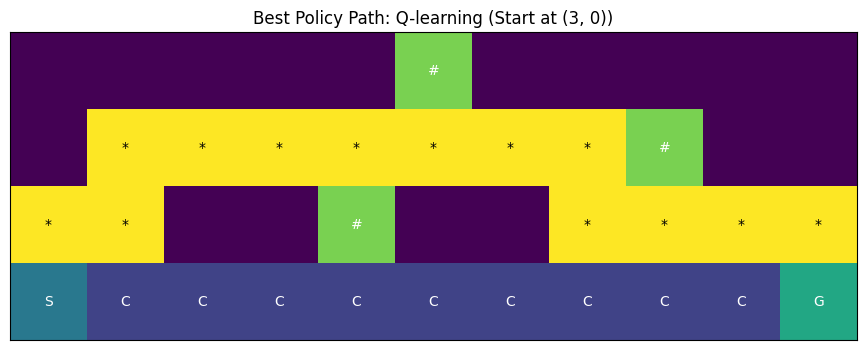

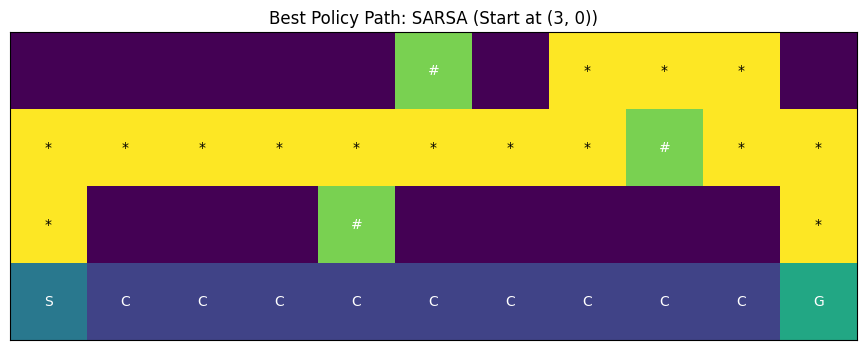

In [84]:
CliffWalk(grid3, alpha = 0.1, gamma = 0.9, epsilon = 0.1)

Both algorithms successfully avoiding the obstacles and cliff edge before reaching the goal target. Sarsa takes longer path vs Q-learning.

3rd party code Ref:
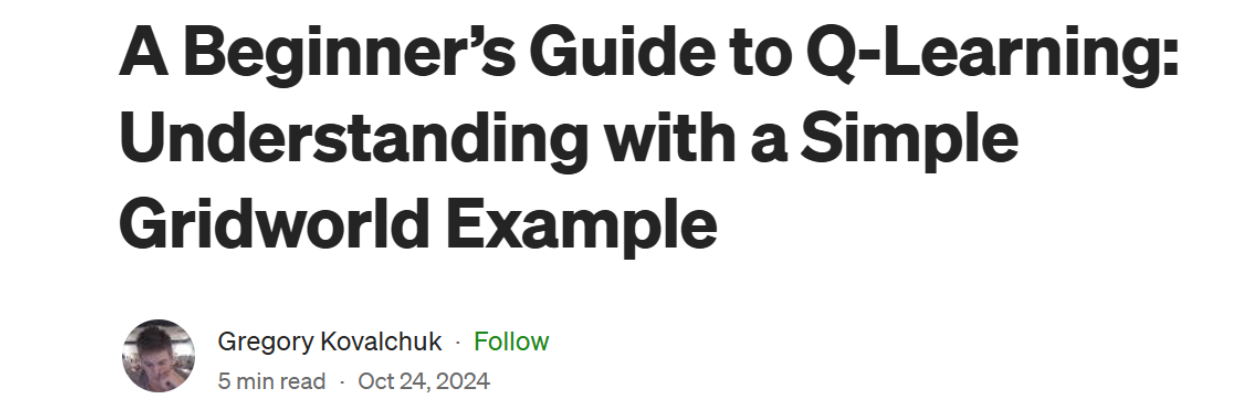
https://medium.com/@goldengrisha/a-beginners-guide-to-q-learning-understanding-with-a-simple-gridworld-example-2b6736e7e2c9

List of changes made to the 3rd party code:\
* Added SARSA algorithm.
* Added obstacles and cliff edge to grid array.
* Added grid visulaization with bst policy path.
* Acumulative reward to track SARSA and Q-learning algorithms. 